<a href="https://colab.research.google.com/github/rayvankaazrifany/Tugas-Besar-NLP/blob/main/NLP_ModellingIndoBERT_absa_richeese.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aspect-Based Sentiment Analysis — Ulasan Richeese Pizza (IndoBERT)



## Install & Import Library

In [ ]:
!pip install -q transformers datasets scikit-learn torch openpyxl


In [ ]:
import ast
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, ConfusionMatrixDisplay,
    hamming_loss, accuracy_score, multilabel_confusion_matrix,
)

import torch
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

assert torch.cuda.is_available(), (
    "GPU tidak terdeteksi! Ke Runtime > Change runtime type > pilih T4 GPU, "
    "lalu run ulang notebook dari cell paling atas."
)

MODEL_NAME = "indobenchmark/indobert-base-p1"
MAX_LEN = 64  # cek distribusi panjang token di Bagian B kalau perlu disesuaikan
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


Device: cuda


config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

## Load Dataset

In [ ]:
df = pd.read_excel("sentiment_aspect_analysis.xlsx")
print("Shape awal:", df.shape)
df.head()


Shape awal: (2011, 11)


,cabang,ulasan,sentiment,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_tosentence,text_akhir,aspect_classification
0,Dago,"pizzanya enak, penasaran coba menu lain",positive,pizza nya enak penasaran coba menu lain,pizza nya enak penasaran coba menu lain,pizza nya enak penasaran coba menu lain,"['pizza', 'nya', 'enak', 'penasaran', 'coba', ...","['pizza', 'nya', 'enak', 'penasaran', 'coba', ...",pizza nya enak penasaran coba menu,pizza nya enak penasaran coba menu,['makanan']
1,Dago,makanan enak pelayanan oke,positive,makanan enak pelayanan oke,makanan enak pelayanan oke,makanan enak pelayanan oke,"['makanan', 'enak', 'pelayanan', 'oke']","['makanan', 'enak', 'pelayanan', 'oke']",makanan enak pelayanan oke,makan enak layan oke,"['makanan', 'pelayanan']"
2,Dago,Menarik mas nya ramah pizza enak,positive,Menarik mas nya ramah pizza enak,menarik mas nya ramah pizza enak,menarik mas nya ramah pizza enak,"['menarik', 'mas', 'nya', 'ramah', 'pizza', 'e...","['menarik', 'mas', 'nya', 'ramah', 'pizza', 'e...",menarik mas nya ramah pizza enak,tarik mas nya ramah pizza enak,"['makanan', 'pelayanan']"
3,Dago,"Pizza nya enak, lembut dan kriuk, tidak alot\n...",positive,Pizza nya enak lembut dan kriuk tidak alot h...,pizza nya enak lembut dan kriuk tidak alot h...,pizza nya enak lembut dan renyah tidak alot ha...,"['pizza', 'nya', 'enak', 'lembut', 'dan', 'ren...","['pizza', 'nya', 'enak', 'lembut', 'renyah', '...",pizza nya enak lembut renyah alot harga nya mu...,pizza nya enak lembut renyah alot harga nya mu...,"['makanan', 'pelayanan', 'harga', 'suasana', '..."
4,Dago,best cheeseeee,negative,best cheeseeee,best cheeseeee,best cheeseeee,"['best', 'cheeseeee']","['best', 'cheeseeee']",best cheeseeee,best cheeseeee,"['makanan', 'pelayanan']"


## Data Cleaning

- Drop baris kosong pada kolom teks/sentimen/aspek yang dipakai.
- Parse kolom `aspect_classification` (string list) jadi list Python asli,
  lalu buang label `'None'` (ulasan tanpa aspek eksplisit jadi list kosong,
  bukan kelas tersendiri).

In [ ]:
df = df.dropna(subset=["text_slangwords", "sentiment", "aspect_classification"]).reset_index(drop=True)

aspect_lists_raw = df["aspect_classification"].apply(ast.literal_eval)
df["aspect_list"] = aspect_lists_raw.apply(lambda lst: [a for a in lst if a != "None"])

print("Shape setelah cleaning:", df.shape)
df[["text_slangwords", "sentiment", "aspect_list"]].head()


Shape setelah cleaning: (2011, 12)


,text_slangwords,sentiment,aspect_list
0,pizza nya enak penasaran coba menu lain,positive,[makanan]
1,makanan enak pelayanan oke,positive,"[makanan, pelayanan]"
2,menarik mas nya ramah pizza enak,positive,"[makanan, pelayanan]"
3,pizza nya enak lembut dan renyah tidak alot ha...,positive,"[makanan, pelayanan, harga, suasana, fasilitas]"
4,best cheeseeee,negative,"[makanan, pelayanan]"


# EDA

## Distribusi Sentimen (Pie Chart)
Sentimen single-label -> pie chart representatif untuk melihat imbalance.

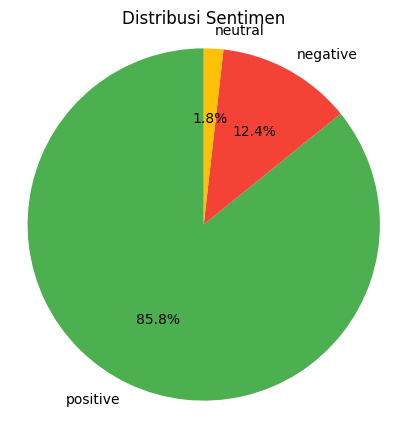

sentiment
positive    1726
negative     249
neutral       36
Name: count, dtype: int64


In [ ]:
sentiment_counts = df["sentiment"].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4CAF50", "#F44336", "#FFC107"],
)
plt.title("Distribusi Sentimen")
plt.axis("equal")
plt.show()
print(sentiment_counts)


## Frekuensi Aspek (Bar Chart)
rekuensi kemunculan tiap aspek.

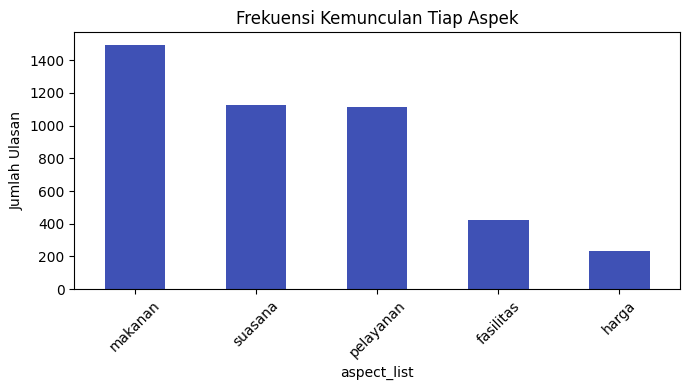

aspect_list
makanan      1496
suasana      1128
pelayanan    1112
fasilitas     423
harga         235
Name: count, dtype: int64


In [ ]:
all_aspects = df["aspect_list"].explode().dropna()
aspect_freq = all_aspects.value_counts()

plt.figure(figsize=(7, 4))
aspect_freq.plot(kind="bar", color="#3F51B5")
plt.title("Frekuensi Kemunculan Tiap Aspek")
plt.ylabel("Jumlah Ulasan")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print(aspect_freq)


## Jumlah Aspek per Ulasan (Cardinality)

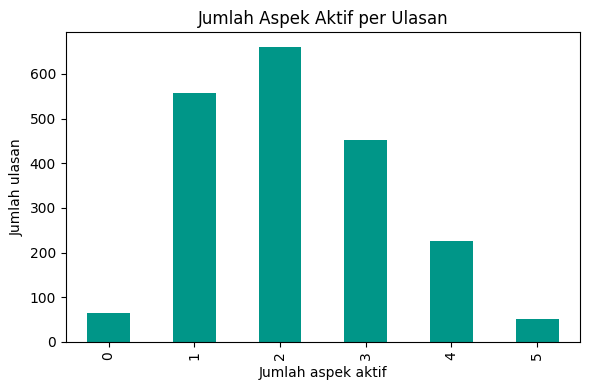

aspect_list
0     65
1    557
2    660
3    451
4    226
5     52
Name: count, dtype: int64


In [ ]:
cardinality = df["aspect_list"].apply(len)

plt.figure(figsize=(6, 4))
cardinality.value_counts().sort_index().plot(kind="bar", color="#009688")
plt.title("Jumlah Aspek Aktif per Ulasan")
plt.xlabel("Jumlah aspek aktif")
plt.ylabel("Jumlah ulasan")
plt.tight_layout()
plt.show()
print(cardinality.value_counts().sort_index())


## Cek Panjang Teks (opsional, untuk validasi MAX_LEN)

In [ ]:
token_lengths = df["text_slangwords"].apply(lambda x: len(str(x).split()))
print(token_lengths.describe())
print("95th percentile:", int(token_lengths.quantile(0.95)))


count    2011.000000
mean       16.635007
std        25.018621
min         1.000000
25%         5.000000
50%        10.000000
75%        17.000000
max       300.000000
Name: text_slangwords, dtype: float64
95th percentile: 52


# Model Sentimen (Single-label)

Target: `sentiment` (3 kelas). Output softmax, loss `CrossEntropyLoss`
dengan **class weighting** untuk menangani imbalance (positive 85% vs
neutral 1.8%).

## Encoding Label

In [ ]:
le_sentiment = LabelEncoder()
df["sentiment_label"] = le_sentiment.fit_transform(df["sentiment"])
print(dict(zip(le_sentiment.classes_, le_sentiment.transform(le_sentiment.classes_))))


{'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}


## Train / Val / Test Split
Stratified berdasarkan label sentimen.

In [ ]:
X_sent = df["text_slangwords"].values
y_sent = df["sentiment_label"].values

X_train_s, X_temp_s, y_train_s, y_temp_s = train_test_split(
    X_sent, y_sent, test_size=0.2, stratify=y_sent, random_state=SEED
)
X_val_s, X_test_s, y_val_s, y_test_s = train_test_split(
    X_temp_s, y_temp_s, test_size=0.5, stratify=y_temp_s, random_state=SEED
)

print("Train:", len(X_train_s), "Val:", len(X_val_s), "Test:", len(X_test_s))
print("Distribusi train:", np.bincount(y_train_s))


Train: 1608 Val: 201 Test: 202
Distribusi train: [ 199   29 1380]


## Class Weighting
Dihitung dari data train saja.

In [ ]:
class_weights = compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train_s), y=y_train_s
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

for cls, w in zip(le_sentiment.classes_, class_weights.cpu().numpy()):
    print(f"Kelas '{cls}': bobot = {w:.3f}")


Kelas 'negative': bobot = 2.693
Kelas 'neutral': bobot = 18.483
Kelas 'positive': bobot = 0.388


## Tokenisasi & Dataset

In [ ]:
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=MAX_LEN):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]), truncation=True, padding="max_length",
            max_length=self.max_len, return_tensors="pt",
        )
        item = {k: v.squeeze(0) for k, v in encoding.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

sent_train_ds = SentimentDataset(X_train_s, y_train_s, tokenizer)
sent_val_ds = SentimentDataset(X_val_s, y_val_s, tokenizer)
sent_test_ds = SentimentDataset(X_test_s, y_test_s, tokenizer)


## Modeling: Fine-tuning IndoBERT (Weighted CrossEntropyLoss)

In [ ]:
sentiment_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=len(le_sentiment.classes_)
).to(device)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

def compute_metrics_sentiment(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": (preds == labels).mean(),
        "macro_f1": f1_score(labels, preds, average="macro"),
    }

sentiment_args = TrainingArguments(
    output_dir="./indobert-sentiment-richeese",
    num_train_epochs=4,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    logging_steps=20,
    fp16=torch.cuda.is_available(),
    seed=SEED,
)

sentiment_trainer = WeightedTrainer(
    model=sentiment_model,
    args=sentiment_args,
    train_dataset=sent_train_ds,
    eval_dataset=sent_val_ds,
    compute_metrics=compute_metrics_sentiment,
)

sentiment_trainer.train()


[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  498MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  498MB            

model.safetensors: downloading bytes:           |  0.00B            

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=204, training_loss=0.4197329104531045, metrics={'train_runtime': 126.3101, 'train_samples_per_second': 50.922, 'train_steps_per_second': 1.615, 'total_flos': 211543187853312.0, 'train_loss': 0.4197329104531045, 'epoch': 4.0})

## Evaluasi Model Sentimen

              precision    recall  f1-score   support

    negative     0.7391    0.6800    0.7083        25
     neutral     0.7500    0.7500    0.7500         4
    positive     0.9600    0.9711    0.9655       173

    accuracy                         0.9307       202
   macro avg     0.8164    0.8004    0.8080       202
weighted avg     0.9285    0.9307    0.9294       202



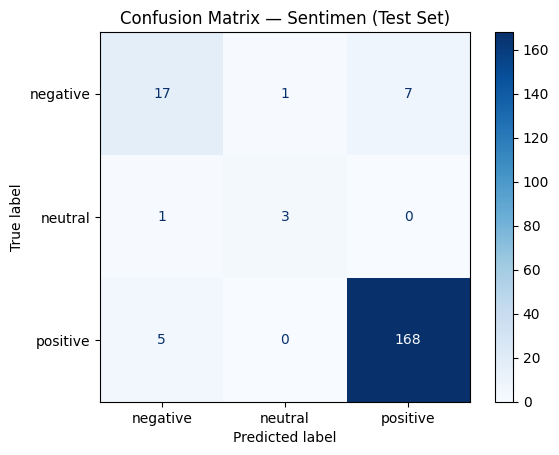

Macro F1-score (sentimen): 0.8079501915708813


In [ ]:
pred_output_s = sentiment_trainer.predict(sent_test_ds)
y_pred_s = np.argmax(pred_output_s.predictions, axis=-1)

print(classification_report(
    y_test_s, y_pred_s, target_names=le_sentiment.classes_, digits=4
))

cm_s = confusion_matrix(y_test_s, y_pred_s)
disp_s = ConfusionMatrixDisplay(confusion_matrix=cm_s, display_labels=le_sentiment.classes_)
disp_s.plot(cmap="Blues")
plt.title("Confusion Matrix — Sentimen (Test Set)")
plt.savefig("confusion_matrix_sentiment.png", dpi=300, bbox_inches="tight")
plt.show()

print("Macro F1-score (sentimen):", f1_score(y_test_s, y_pred_s, average="macro"))


# Model Aspek (Multi-label)

Target: `aspect_list` (5 kelas, bisa >1 aktif sekaligus per ulasan).
Output sigmoid per kelas, loss `BCEWithLogitsLoss` dengan **`pos_weight`**
sebagai bentuk class weighting versi multi-label.

## Encoding Label (MultiLabelBinarizer)

In [ ]:
mlb = MultiLabelBinarizer()
y_aspect = mlb.fit_transform(df["aspect_list"])
aspect_classes = list(mlb.classes_)

print("Kelas aspek:", aspect_classes)
print("Shape label:", y_aspect.shape)
pd.DataFrame(y_aspect, columns=aspect_classes).head()


Kelas aspek: ['fasilitas', 'harga', 'makanan', 'pelayanan', 'suasana']
Shape label: (2011, 5)


,fasilitas,harga,makanan,pelayanan,suasana
0,0,0,1,0,0
1,0,0,1,1,0
2,0,0,1,1,0
3,1,1,1,1,1
4,0,0,1,1,0


## Train / Val / Test Split
Untuk multi-label, split biasa (bukan stratified sempurna karena kombinasi
label terlalu beragam), lalu verifikasi proporsi tiap label di tiap subset.

In [ ]:
X_asp = df["text_slangwords"].values

X_train_a, X_temp_a, y_train_a, y_temp_a = train_test_split(
    X_asp, y_aspect, test_size=0.2, random_state=SEED
)
X_val_a, X_test_a, y_val_a, y_test_a = train_test_split(
    X_temp_a, y_temp_a, test_size=0.5, random_state=SEED
)

print("Train:", len(X_train_a), "Val:", len(X_val_a), "Test:", len(X_test_a))
print("\nProporsi tiap label (train):")
print(pd.DataFrame(y_train_a, columns=aspect_classes).mean().round(3))


Train: 1608 Val: 201 Test: 202

Proporsi tiap label (train):
fasilitas    0.212
harga        0.116
makanan      0.743
pelayanan    0.553
suasana      0.558
dtype: float64


## Class Weighting Multi-label (`pos_weight`)
Dihitung dari rasio negatif:positif tiap label, dari data train saja.

In [ ]:
def compute_pos_weight(y_train):
    n_samples = y_train.shape[0]
    n_pos = y_train.sum(axis=0)
    n_neg = n_samples - n_pos
    pos_weight = n_neg / np.clip(n_pos, 1, None)
    return torch.tensor(pos_weight, dtype=torch.float)

pos_weight = compute_pos_weight(y_train_a).to(device)

for cls, w in zip(aspect_classes, pos_weight.cpu().numpy()):
    print(f"Aspek '{cls}': pos_weight = {w:.3f}")


Aspek 'fasilitas': pos_weight = 3.716
Aspek 'harga': pos_weight = 7.645
Aspek 'makanan': pos_weight = 0.347
Aspek 'pelayanan': pos_weight = 0.807
Aspek 'suasana': pos_weight = 0.793


## Tokenisasi & Dataset

In [ ]:
class AspectDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=MAX_LEN):
        self.texts = list(texts)
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]), truncation=True, padding="max_length",
            max_length=self.max_len, return_tensors="pt",
        )
        item = {k: v.squeeze(0) for k, v in encoding.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.float)  # float untuk BCE
        return item

asp_train_ds = AspectDataset(X_train_a, y_train_a, tokenizer)
asp_val_ds = AspectDataset(X_val_a, y_val_a, tokenizer)
asp_test_ds = AspectDataset(X_test_a, y_test_a, tokenizer)


## Modeling: Fine-tuning IndoBERT (Weighted BCEWithLogitsLoss)

In [ ]:
aspect_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(aspect_classes),
    problem_type="multi_label_classification",
).to(device)

class WeightedMultiLabelTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics_aspect(eval_pred):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits))
    preds = (probs >= 0.5).astype(int)
    return {
        "micro_f1": f1_score(labels, preds, average="micro", zero_division=0),
        "macro_f1": f1_score(labels, preds, average="macro", zero_division=0),
        "hamming_loss": hamming_loss(labels, preds),
        "subset_accuracy": accuracy_score(labels, preds),
    }

aspect_args = TrainingArguments(
    output_dir="./indobert-aspect-richeese",
    num_train_epochs=4,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    logging_steps=20,
    fp16=torch.cuda.is_available(),
    seed=SEED,
)

aspect_trainer = WeightedMultiLabelTrainer(
    model=aspect_model,
    args=aspect_args,
    train_dataset=asp_train_ds,
    eval_dataset=asp_val_ds,
    compute_metrics=compute_metrics_aspect,
)

aspect_trainer.train()


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Micro F1,Macro F1,Hamming Loss,Subset Accuracy,Runtime,Samples Per Second,Steps Per Second
1,0.521361,0.341534,0.850056,0.815955,0.132338,0.507463,0.310900,646.455000,22.513000
2,0.259217,0.216119,0.908224,0.911327,0.076617,0.686567,0.253200,793.895000,27.648000
3,0.185910,0.179588,0.921084,0.920916,0.066667,0.726368,0.260000,773.051000,26.922000
4,0.148866,0.168656,0.925969,0.922099,0.062687,0.736318,0.257800,779.702000,27.154000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=204, training_loss=0.2938816328259075, metrics={'train_runtime': 233.2133, 'train_samples_per_second': 27.58, 'train_steps_per_second': 0.875, 'total_flos': 211546986541056.0, 'train_loss': 0.2938816328259075, 'epoch': 4.0})

## Evaluasi Model Aspek

In [ ]:
pred_output_a = aspect_trainer.predict(asp_test_ds)
probs_a = 1 / (1 + np.exp(-pred_output_a.predictions))
y_pred_a = (probs_a >= 0.5).astype(int)

print(classification_report(
    y_test_a, y_pred_a, target_names=aspect_classes, digits=4, zero_division=0
))

print("Micro F1        :", f1_score(y_test_a, y_pred_a, average="micro", zero_division=0))
print("Macro F1         :", f1_score(y_test_a, y_pred_a, average="macro", zero_division=0))
print("Hamming Loss     :", hamming_loss(y_test_a, y_pred_a))
print("Subset Accuracy  :", accuracy_score(y_test_a, y_pred_a))


              precision    recall  f1-score   support

   fasilitas     0.7447    0.8333    0.7865        42
       harga     0.9565    0.9167    0.9362        24
     makanan     0.9922    0.8411    0.9104       151
   pelayanan     0.9823    0.9487    0.9652       117
     suasana     0.9633    0.9052    0.9333       116

   micro avg     0.9524    0.8889    0.9195       450
   macro avg     0.9278    0.8890    0.9063       450
weighted avg     0.9572    0.8889    0.9204       450
 samples avg     0.9333    0.8755    0.8887       450

Micro F1        : 0.9195402298850575
Macro F1         : 0.9063264113138396
Hamming Loss     : 0.06930693069306931
Subset Accuracy  : 0.7277227722772277


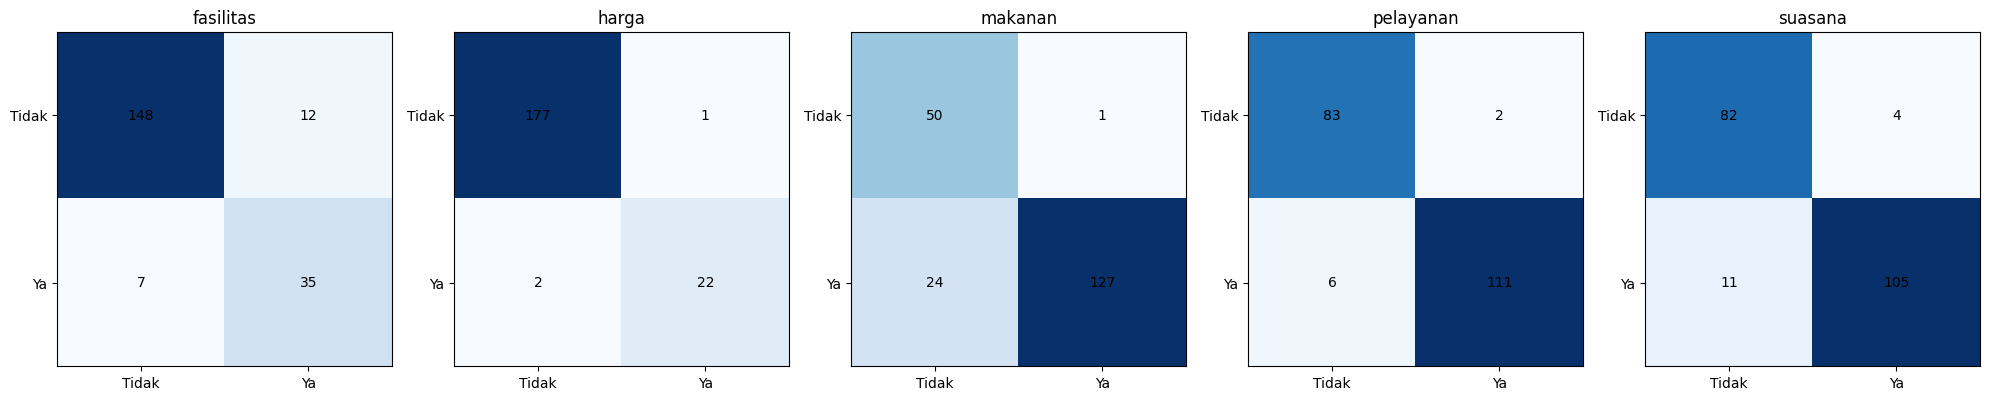

In [ ]:
mcm = multilabel_confusion_matrix(y_test_a, y_pred_a)

fig, axes = plt.subplots(1, len(aspect_classes), figsize=(4 * len(aspect_classes), 4))
for i, (cls, cm) in enumerate(zip(aspect_classes, mcm)):
    ax = axes[i]
    ax.imshow(cm, cmap="Blues")
    ax.set_title(cls)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Tidak", "Ya"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Tidak", "Ya"])
    for r in range(2):
        for c in range(2):
            ax.text(c, r, cm[r, c], ha="center", va="center")
plt.tight_layout()
plt.savefig("confusion_matrix_aspect.png", dpi=300, bbox_inches="tight")
plt.show()


# Menyimpan Kedua Model



In [ ]:
# --- Model Sentimen ---
sent_save_dir = "./indobert-sentiment-final"
sentiment_trainer.save_model(sent_save_dir)
tokenizer.save_pretrained(sent_save_dir)

with open(f"{sent_save_dir}/label_map.json", "w") as f:
    json.dump({int(i): label for i, label in enumerate(le_sentiment.classes_)}, f, indent=2)

# --- Model Aspek ---
asp_save_dir = "./indobert-aspect-final"
aspect_trainer.save_model(asp_save_dir)
tokenizer.save_pretrained(asp_save_dir)

with open(f"{asp_save_dir}/aspect_label_map.json", "w") as f:
    json.dump({int(i): cls for i, cls in enumerate(aspect_classes)}, f, indent=2)

!zip -r indobert-sentiment-final.zip {sent_save_dir}
!zip -r indobert-aspect-final.zip {asp_save_dir}

print("Kedua model tersimpan.")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  adding: indobert-sentiment-final/ (stored 0%)
  adding: indobert-sentiment-final/tokenizer_config.json (deflated 43%)
  adding: indobert-sentiment-final/model.safetensors (deflated 7%)
  adding: indobert-sentiment-final/tokenizer.json (deflated 71%)
  adding: indobert-sentiment-final/config.json (deflated 57%)
  adding: indobert-sentiment-final/label_map.json (deflated 24%)
  adding: indobert-sentiment-final/training_args.bin (deflated 54%)
  adding: indobert-aspect-final/ (stored 0%)
  adding: indobert-aspect-final/aspect_label_map.json (deflated 29%)
  adding: indobert-aspect-final/tokenizer_config.json (deflated 43%)
  adding: indobert-aspect-final/model.safetensors (deflated 7%)
  adding: indobert-aspect-final/tokenizer.json (deflated 71%)
  adding: indobert-aspect-final/config.json (deflated 58%)
  adding: indobert-aspect-final/training_args.bin (deflated 54%)
Kedua model tersimpan.


## Catatan Penggunaan Saat Inference (mis. di Streamlit)

```python
import torch, json
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# Load kedua model
sent_model = AutoModelForSequenceClassification.from_pretrained("indobert-sentiment-final")
sent_tokenizer = AutoTokenizer.from_pretrained("indobert-sentiment-final")
with open("indobert-sentiment-final/label_map.json") as f:
    sentiment_label_map = json.load(f)

asp_model = AutoModelForSequenceClassification.from_pretrained("indobert-aspect-final")
asp_tokenizer = AutoTokenizer.from_pretrained("indobert-aspect-final")
with open("indobert-aspect-final/aspect_label_map.json") as f:
    aspect_label_map = json.load(f)

def predict(text):
    # Sentimen: argmax (single-label)
    inputs = sent_tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=64)
    with torch.no_grad():
        logits = sent_model(**inputs).logits
    sentiment = sentiment_label_map[str(torch.argmax(logits, dim=-1).item())]

    # Aspek: threshold 0.5 (multi-label)
    inputs = asp_tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=64)
    with torch.no_grad():
        logits = asp_model(**inputs).logits
    probs = torch.sigmoid(logits).squeeze().tolist()
    aspects = [aspect_label_map[str(i)] for i, p in enumerate(probs) if p >= 0.5]

    return {"sentiment": sentiment, "aspects": aspects}

print(predict("makanannya enak banget tapi pelayanannya lama"))
```
